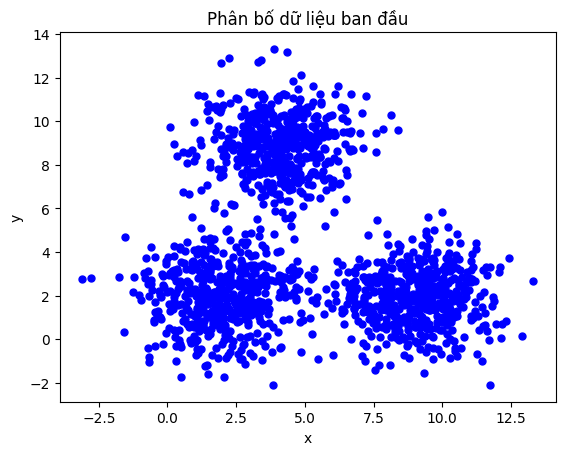

Tâm cụm khởi tạo:
 [[2.92075066 3.95292461]
 [2.40778271 6.16565756]
 [3.19990825 3.02125185]]


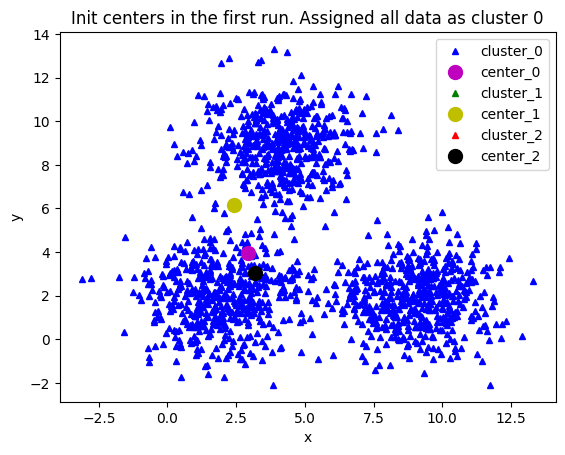

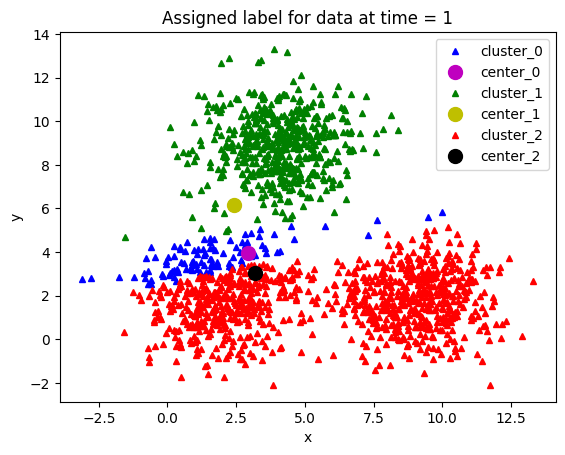

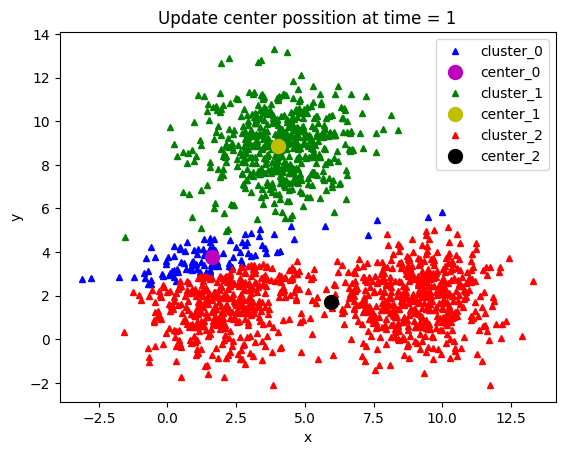

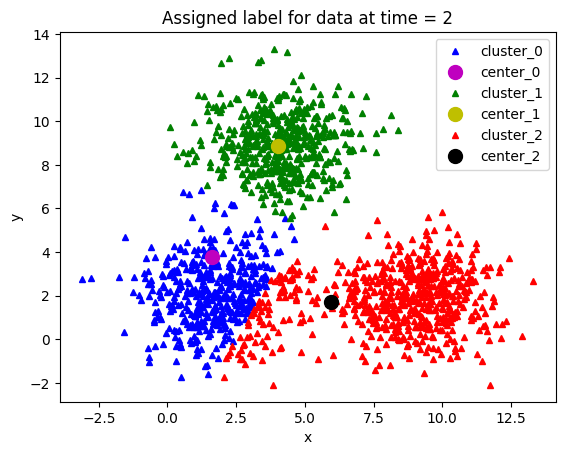

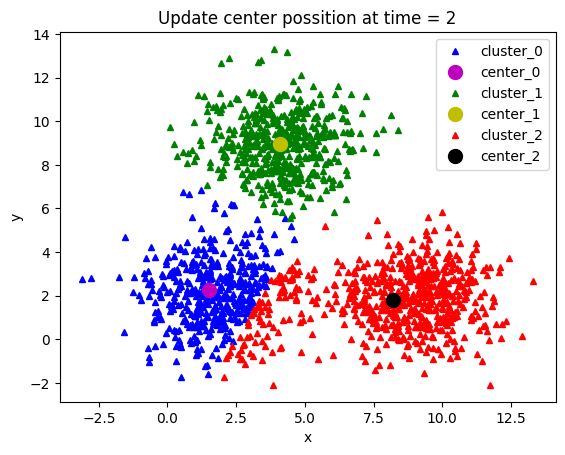

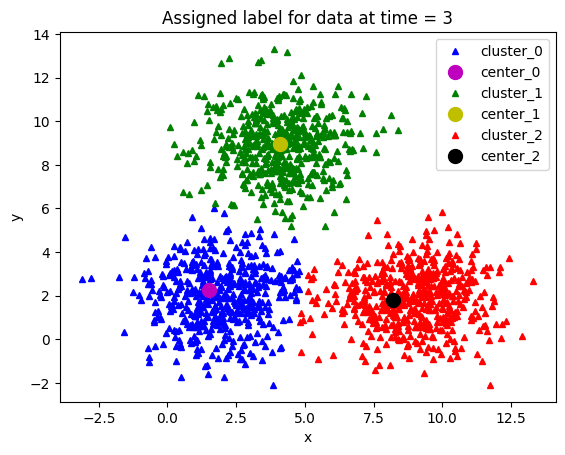

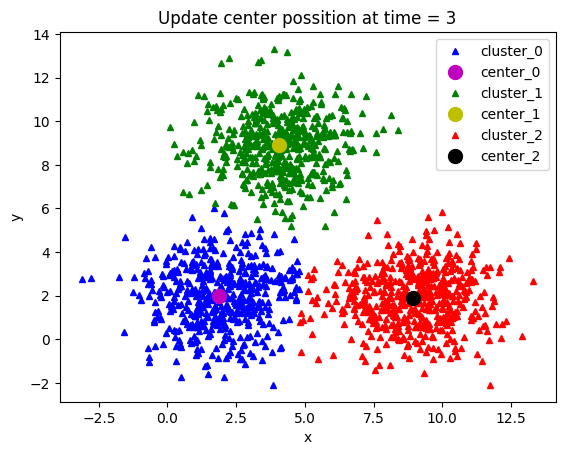

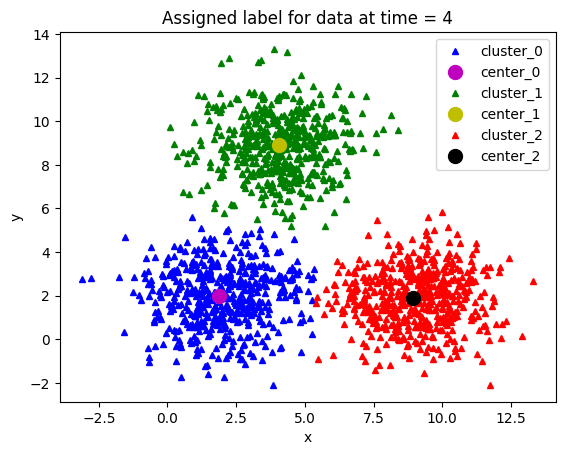

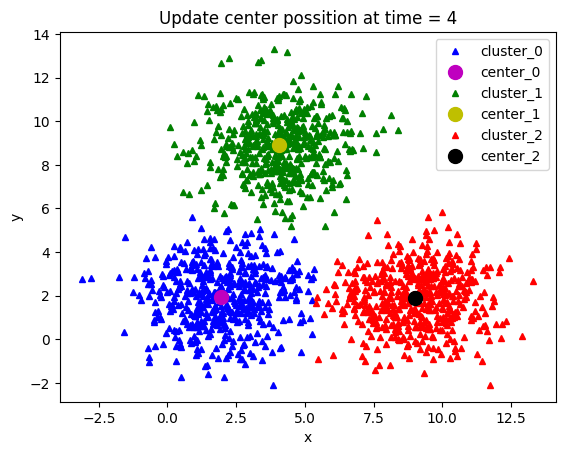

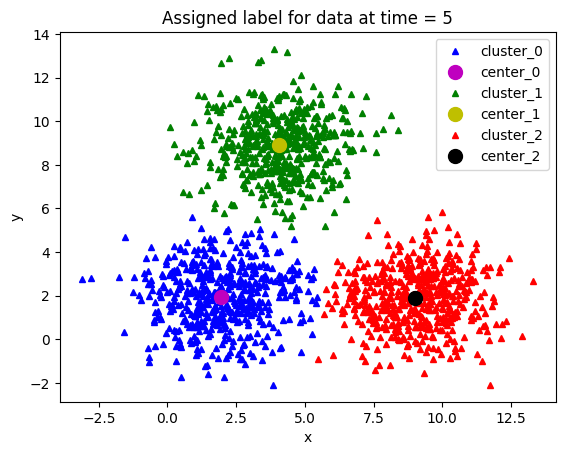

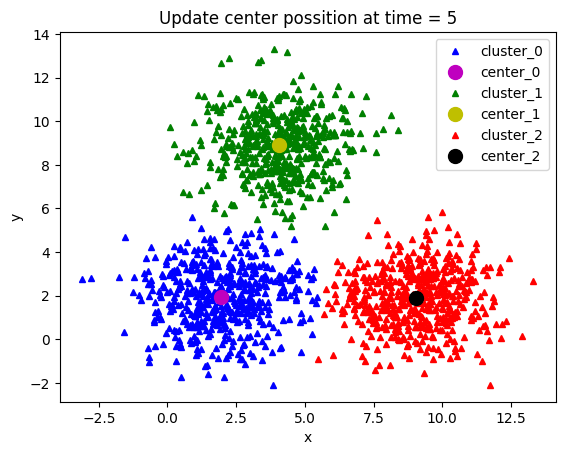

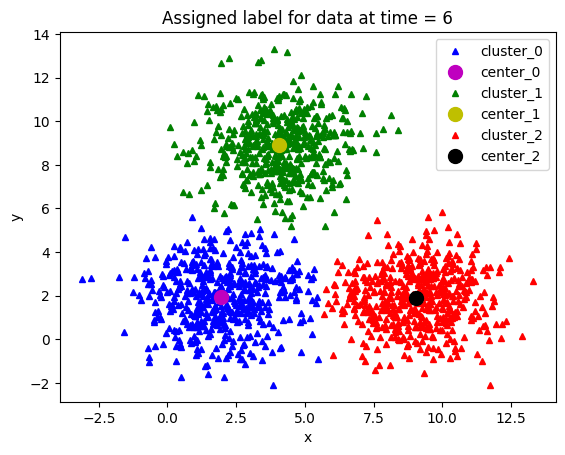

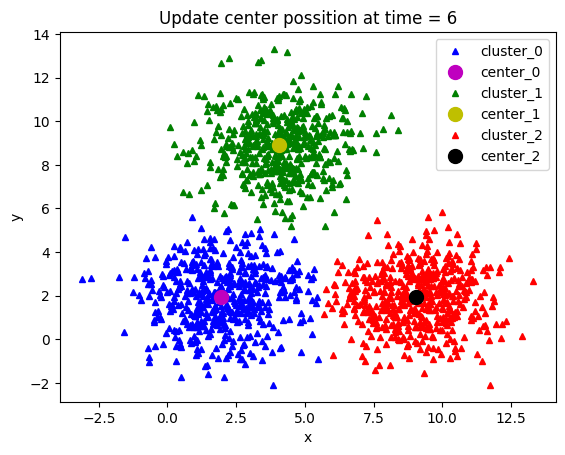

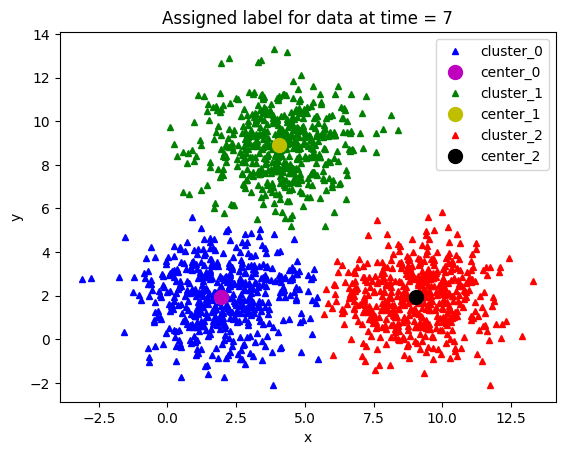

Done! K-Means has converged after 6 times
Tọa độ các tâm cụm cuối cùng:
 [[1.96230168 1.94311766]
 [4.06136996 8.88877956]
 [9.03691054 1.91633716]]


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist

# --- KHỞI TẠO DỮ LIỆU MẪU ---
means = [[2, 2], [9, 2], [4, 9]]
cov = [[2, 0], [0, 2]]
n_samples = 500
n_cluster = 3

X0 = np.random.multivariate_normal(means[0], cov, n_samples)
X1 = np.random.multivariate_normal(means[1], cov, n_samples)
X2 = np.random.multivariate_normal(means[2], cov, n_samples)
X = np.concatenate((X0, X1, X2), axis=0)

# --- CÁC HÀM XỬ LÝ CỦA THUẬT TOÁN K-MEANS ---

def kmeans_init_centers(X, n_cluster):
    """Khởi tạo ngẫu nhiên n_cluster tâm cụm từ tập dữ liệu X"""
    return X[np.random.choice(X.shape[0], n_cluster, replace=False)]

def kmeans_predict_labels(X, centers):
    """Tính khoảng cách từ các điểm đến các tâm và gán nhãn cho điểm gần tâm nhất"""
    D = cdist(X, centers)
    return np.argmin(D, axis=1)

def kmeans_update_centers(X, labels, n_cluster):
    """Cập nhật lại tọa độ tâm cụm bằng trung bình cộng các điểm trong cụm đó"""
    centers = np.zeros((n_cluster, X.shape[1]))
    for k in range(n_cluster):
        Xk = X[labels == k, :]
        centers[k, :] = np.mean(Xk, axis=0)
    return centers

def kmeans_has_converged(centers, new_centers):
    """Kiểm tra xem thuật toán đã hội tụ chưa (tâm cụm không đổi vị trí)"""
    return (set([tuple(a) for a in centers]) == set([tuple(a) for a in new_centers]))

def kmeans_visualize(X, centers, labels, n_cluster, title):
    """Vẽ dữ liệu và tâm cụm lên đồ thị"""
    plt.xlabel('x')
    plt.ylabel('y')
    plt.title(title)
    plt_colors = ['b', 'g', 'r', 'c', 'm', 'y', 'k', 'w']

    for i in range(n_cluster):
        data = X[labels == i]
        plt.plot(data[:, 0], data[:, 1], plt_colors[i] + '^', markersize=4, label='cluster_' + str(i))
        plt.plot(centers[i][0], centers[i][1], plt_colors[i + 4] + 'o', markersize=10, label='center_' + str(i))

    plt.legend()
    plt.show()

def kmeans(init_centes, init_labels, X, n_cluster):
    """Vòng lặp chính của thuật toán K-Means"""
    centers = init_centes
    labels = init_labels
    times = 0
    while True:
        labels = kmeans_predict_labels(X, centers)
        kmeans_visualize(X, centers, labels, n_cluster, 'Assigned label for data at time = ' + str(times + 1))

        new_centers = kmeans_update_centers(X, labels, n_cluster)
        if kmeans_has_converged(centers, new_centers):
            break

        centers = new_centers
        kmeans_visualize(X, centers, labels, n_cluster, 'Update center possition at time = ' + str(times + 1))
        times += 1

    return (centers, labels, times)

# --- CHƯƠNG TRÌNH CHÍNH ---
if __name__ == "__main__":
    # Xem phân bố dữ liệu ban đầu
    plt.figure()
    plt.title("Phân bố dữ liệu ban đầu")
    plt.xlabel('x')
    plt.ylabel('y')
    plt.plot(X[:, 0], X[:, 1], 'bo', markersize=5)
    plt.show()

    # Thực thi K-Means
    init_centers = kmeans_init_centers(X, n_cluster)
    print("Tâm cụm khởi tạo:\n", init_centers)

    init_labels = np.zeros(X.shape[0])
    kmeans_visualize(X, init_centers, init_labels, n_cluster, 'Init centers in the first run. Assigned all data as cluster 0')

    centers, labels, times = kmeans(init_centers, init_labels, X, n_cluster)

    print('Done! K-Means has converged after', times, 'times')
    print("Tọa độ các tâm cụm cuối cùng:\n", centers)